# Laboratorio de Machine Learning con Wine Quality (vino tinto)


## Por: Luciana Carabaguiaz, Diego Diaz, Julián Maroto, Santiago Volio

En este notebook trabajaremos con el dataset `winequality-red.csv` para construir un problema de clasificación binaria.

Definiremos la variable objetivo de la siguiente forma:

- **Bueno (1)** si `quality >= 7`
- **No bueno (0)** si `quality <= 6`

Desde el punto de vista algebraico, si tenemos `n` observaciones y `d` variables predictoras, el conjunto de datos puede representarse como una matriz:

\[
X \in \mathbb{R}^{n \times d}
\]

donde cada fila \(x_i^T\) representa un vino en \(\mathbb{R}^d\). La tarea de clasificación busca una función

\[
f : \mathbb{R}^d \to \{0,1\}
\]

que asigne una clase a cada vector de características.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

# Actividad A — Carga, limpieza y formulación algebraica

En esta sección se carga el dataset, se construye la etiqueta binaria y se separan los datos en entrenamiento y prueba.

Si el dataset contiene \(n\) filas y \(d\) variables predictoras, entonces:

- \(X \in \mathbb{R}^{n \times d}\) es la matriz de características.
- \(y \in \{0,1\}^n\) es el vector de etiquetas.

Cada fila \(x_i^T\) de \(X\) corresponde a un vino descrito por 11 propiedades fisicoquímicas.

In [ ]:
# Leer df
df = pd.read_csv("winequality-red.csv", sep=None, engine="python")

print("Dimensiones del dataset original:", df.shape)
display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

print("\nValores faltantes por columna:")
print(df.isna().sum())

# Crear etiqueta binaria
df["target"] = (df["quality"] >= 7).astype(int)

# Separar variables
X = df.drop(columns=["quality", "target"])
y = df["target"]

print("\nDimensiones algebraicas:")
print(f"X tiene forma {X.shape} -> matriz en R^(n x d)")
print(f"y tiene forma {y.shape} -> vector en R^n")

print("\nDistribución de clases:")
print(y.value_counts().sort_index())
print("\nProporciones:")
print(y.value_counts(normalize=True).sort_index())

# Split train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nShapes del split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Dimensiones del dataset original: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Columnas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Dimensiones algebraicas:
X tiene forma (1599, 11) -> matriz en R^(n x d)
y tiene forma (1599,) -> vector en R^n

Distribución de clases:
target
0    1382
1     217
Name: count, dtype: int64

Proporciones:
target
0    0.86429
1    0.13571
Name: proportion, dtype: float64

Shapes del split:
X_train: (1279, 11)
X_test : (320, 11)
y_train: (1279,)
y_test : (320,)


# Actividad B — Preprocesamiento con sentido geométrico

Escalar tiene sentido geométrico. En **kNN**, la clasificación depende de distancias como la norma euclídea, por lo que una variable con valores numéricamente grandes puede dominar la cercanía entre puntos. En modelos lineales como SVM, regresión logística y perceptrón, la decisión depende del producto interno \(w^T x\), así que la escala de cada coordenada influye directamente en la orientación del hiperplano. Por eso, estandarizar ayuda a que las variables participen de forma más equilibrada en la geometría del problema.

In [ ]:
def build_pipeline(model, scale=True):

    if scale:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        return Pipeline([
            ("model", model)
        ])

def fit_evaluate(model, X_train, X_test, y_train, y_test, scale=True, nombre_modelo="", parametros=""):

    pipe = build_pipeline(model, scale=scale)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "Algoritmo": nombre_modelo,
        "Accuracy": acc,
        "F1": f1,
        "Parámetros": parametros,
        "Escalado": scale,
        "Pipeline": pipe
    }

# Actividad C — Implementación de 6 algoritmos + lectura algebraica

En esta sección se usarán los mismos conjuntos `train/test` para todos los modelos y se compararán con las métricas **accuracy** y **F1**.

## Lecturas algebraicas

### 1. k-Nearest Neighbors
La distancia euclídea entre dos puntos \(x\) y \(z\) es:

\[
\|x-z\|_2 = \sqrt{(x-z)^T(x-z)}
\]

Comparar \(\|x-z\|_2^2\) es equivalente para decidir cuál punto está más cerca, porque la raíz cuadrada es una función monótona creciente. Algebraicamente, usar la distancia al cuadrado es más simple.

### 2. SVM lineal
La frontera de decisión de un SVM lineal se escribe como:

\[
w^T x + b = 0
\]

La distancia de un punto \(x\) al hiperplano es:

\[
\frac{|w^T x + b|}{\|w\|}
\]

Maximizar el margen significa separar las clases con el hiperplano que deja la mayor distancia posible respecto a los puntos más cercanos de cada clase.

### 3. Regresión logística
La regresión logística usa un score lineal:

\[
s = w^T x + b
\]

y luego aplica una sigmoide para convertir ese score en probabilidad. Sin embargo, la frontera de decisión binaria ocurre cuando \(s = 0\), así que sigue siendo un hiperplano.

### 4. Perceptrón
La regla clásica de actualización puede escribirse como:

\[
w \leftarrow w + \eta yx,\qquad b \leftarrow b + \eta y
\]

cuando hay error de clasificación. Geométricamente, esto ajusta la posición y orientación del hiperplano para corregir errores.

### 5. Naive Bayes Gaussiano
En distribuciones gaussianas aparece una forma cuadrática parecida a una distancia de Mahalanobis:

\[
(x-\mu)^T \Sigma^{-1}(x-\mu)
\]

Si \(\Sigma\) es diagonal, el modelo trata cada variable como independiente dentro de cada clase, lo cual equivale a usar una métrica sin términos cruzados entre variables.

### 6. Árboles de decisión
Cada split del árbol tiene la forma \(x_j = t\), o sea, un corte alineado con un eje. Por eso el árbol construye regiones rectangulares o hiperrrectángulos en \(\mathbb{R}^d\), a diferencia de un hiperplano oblicuo como \(w^T x + b = 0\).

In [ ]:
resultados = []


# C1) kNN
for k in [3, 5, 11]:
    res = fit_evaluate(
        model=KNeighborsClassifier(n_neighbors=k),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=True,
        nombre_modelo="kNN",
        parametros=f"k={k}"
    )
    resultados.append(res)


# C2) SVM lineal
for C in [0.1, 1, 10]:
    res = fit_evaluate(
        model=LinearSVC(C=C, random_state=RANDOM_STATE, dual=False, max_iter=5000),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=True,
        nombre_modelo="SVM lineal",
        parametros=f"C={C}"
    )
    resultados.append(res)


# C3) Regresión logística
for C in [0.1, 1]:
    res = fit_evaluate(
        model=LogisticRegression(
            penalty="l2",
            C=C,
            random_state=RANDOM_STATE,
            max_iter=5000
        ),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=True,
        nombre_modelo="Regresión Logística",
        parametros=f"penalty=l2, C={C}"
    )
    resultados.append(res)

# C4) Perceptrón
for eta0 in [0.001, 0.01]:
    res = fit_evaluate(
        model=Perceptron(
            eta0=eta0,
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=True,
        nombre_modelo="Perceptrón",
        parametros=f"eta0={eta0}, max_iter=1000"
    )
    resultados.append(res)

for max_iter in [1000, 3000]:
    res = fit_evaluate(
        model=Perceptron(
            eta0=1.0,
            max_iter=max_iter,
            random_state=RANDOM_STATE
        ),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=True,
        nombre_modelo="Perceptrón",
        parametros=f"eta0=1.0, max_iter={max_iter}"
    )
    resultados.append(res)

# C5) Gaussian Naive Bayes
for scale_option in [False, True]:
    res = fit_evaluate(
        model=GaussianNB(),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=scale_option,
        nombre_modelo="GaussianNB",
        parametros=f"scale={scale_option}"
    )
    resultados.append(res)

# C6) Árboles de decisión
for depth in [2, 4, None]:
    res = fit_evaluate(
        model=DecisionTreeClassifier(
            max_depth=depth,
            random_state=RANDOM_STATE
        ),
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        scale=False,
        nombre_modelo="Árbol de Decisión",
        parametros=f"max_depth={depth}"
    )
    resultados.append(res)

print("Experimentos completados:", len(resultados))

Experimentos completados: 17


# Actividad D — Comparación y conclusiones

En esta sección se construye una tabla resumen con los resultados de todos los modelos y se responde la reflexión final del laboratorio.

In [ ]:
import plotly.express as px

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    by=["Accuracy", "F1"],
    ascending=False
).reset_index(drop=True)

display(tabla_resultados[["Algoritmo", "Accuracy", "F1", "Parámetros", "Escalado"]])

# Visualización interactiva con Plotly
fig = px.bar(
    tabla_resultados,
    x="Accuracy",
    y="Algoritmo",
    color="F1",
    orientation="h",
    title="Comparativa de Modelos: Accuracy vs F1-Score",
    labels={"Accuracy": "Precisión (Accuracy)", "Algoritmo": "Modelo"},
    hover_data=["Parámetros", "Escalado"],
    color_continuous_scale="Viridis"
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

,Algoritmo,Accuracy,F1,Parámetros,Escalado
0,Árbol de Decisión,0.934375,0.734177,max_depth=4,False
1,Árbol de Decisión,0.909375,0.567164,max_depth=2,False
2,kNN,0.906250,0.583333,k=11,True
3,Árbol de Decisión,0.900000,0.644444,max_depth=None,False
4,kNN,0.893750,0.514286,k=5,True
5,Regresión Logística,0.893750,0.484848,"penalty=l2, C=1",True
6,kNN,0.890625,0.545455,k=3,True
7,Regresión Logística,0.887500,0.437500,"penalty=l2, C=0.1",True
8,SVM lineal,0.884375,0.412698,C=1,True
9,SVM lineal,0.884375,0.412698,C=10,True


## Conclusión

El algoritmo que funcionó mejor debe identificarse a partir de la tabla final de resultados. Si el mejor modelo fue lineal, eso puede sugerir que las clases son separables de manera razonable mediante un hiperplano o una aproximación lineal en el espacio de variables transformadas. Si el mejor fue kNN o árbol, entonces podría indicar una frontera de decisión más local o más irregular.

El modelo más sensible al escalado normalmente tiende a ser **kNN**, porque depende directamente de distancias entre puntos, y también suelen verse afectados SVM, regresión logística y perceptrón porque usan productos internos del tipo \(w^T x\). En cambio, los árboles suelen ser mucho menos sensibles a la escala.

Si tuviera que explicar qué es un modelo lineal con lenguaje de álgebra, diría que es un modelo cuya decisión depende de una combinación lineal de las variables, normalmente escrita como \(w^T x + b\). La frontera entre clases aparece cuando esa expresión se iguala a cero, formando un hiperplano en el espacio de características.

In [ ]:
mejor_fila = tabla_resultados.iloc[0]
print("Mejor configuración encontrada:")
print(mejor_fila[["Algoritmo", "Accuracy", "F1", "Parámetros", "Escalado"]])

mejor_pipeline = mejor_fila["Pipeline"]
y_pred_best = mejor_pipeline.predict(X_test)

print("\nClassification report del mejor modelo:\n")
print(classification_report(y_test, y_pred_best))

Mejor configuración encontrada:
Algoritmo     Árbol de Decisión
Accuracy               0.934375
F1                     0.734177
Parámetros          max_depth=4
Escalado                  False
Name: 0, dtype: object

Classification report del mejor modelo:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       277
           1       0.81      0.67      0.73        43

    accuracy                           0.93       320
   macro avg       0.88      0.82      0.85       320
weighted avg       0.93      0.93      0.93       320



# Reto opcional — PCA en 2D

Si deseas agregar nota extra, puedes proyectar los datos a 2 dimensiones con PCA. Algebraicamente, proyectar significa multiplicar la matriz de datos por una matriz de direcciones:

\[
Z = XW
\]

donde \(W\) contiene las direcciones principales y \(Z\) es la representación de los datos en dimensión reducida.

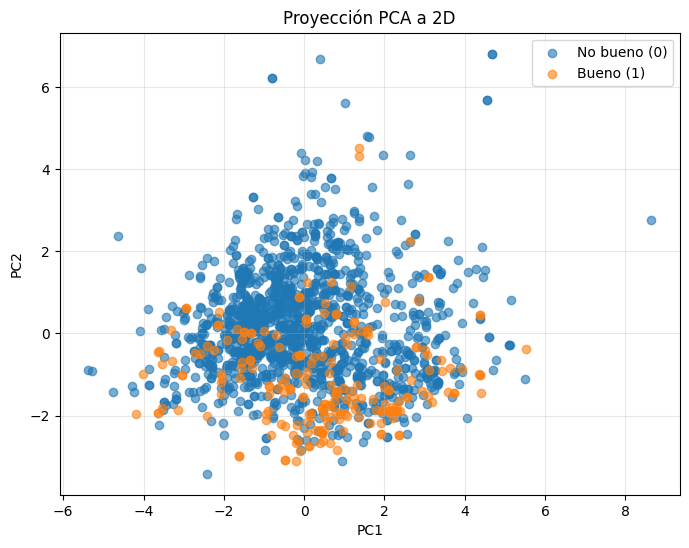

Varianza explicada por las 2 componentes: [0.28173931 0.1750827 ]
Varianza explicada acumulada: 0.4568220118429404


In [ ]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(Z[y == 0, 0], Z[y == 0, 1], alpha=0.6, label="No bueno (0)")
plt.scatter(Z[y == 1, 0], Z[y == 1, 1], alpha=0.6, label="Bueno (1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA a 2D")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())